In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))


In [2]:
refine_plus_export_pool = Path("refine_plus_export_pool")
export_folder = Path("combined_db")
agg_export_path = Path("combined_db_agg.parquet")

In [3]:
# pl.scan_parquet(export_folder).group_by("boulder_id").agg().collect()

filter_df = pl.scan_parquet(export_folder).filter(pl.col("boulder_id") < 40).collect()
filter_df.head()

i,j,face,area,detailed_survey band depth 350,detailed_survey band depth 440,detailed_survey slope 1000,detailed_survey ratio 1000,detailed_survey sigma band depth 350,detailed_survey sigma band depth 440,detailed_survey sigma slope 1000,detailed_survey sigma ratio 1000,recona band depth 350,recona band depth 440,recona slope 1000,recona ratio 1000,recona sigma band depth 350,recona sigma band depth 440,recona sigma slope 1000,recona sigma ratio 1000,reconb band depth 350,reconb band depth 440,reconb slope 1000,reconb ratio 1000,reconb sigma band depth 350,reconb sigma band depth 440,reconb sigma slope 1000,reconb sigma ratio 1000,detailed_survey band depth,detailed_survey reflectance,detailed_survey slope1 poly,detailed_survey slope2 poly,detailed_survey sigma band depth,detailed_survey sigma reflectance,detailed_survey sigma slope1 poly,detailed_survey sigma slope2 poly,recona band depth,recona reflectance,recona slope1 poly,recona slope2 poly,recona sigma band depth,recona sigma reflectance,recona sigma slope1 poly,recona sigma slope2 poly,reconc band depth,reconc reflectance,reconc slope1 poly,reconc slope2 poly,reconc sigma band depth,reconc sigma reflectance,reconc sigma slope1 poly,reconc sigma slope2 poly,uint8_reflectance,32bit_reflectance,positions_x,positions_y,positions_z,detection_lod_level,detection_lod_code,boulder_id
u32,u32,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u8,f32,f32,f32,f32,u8,str,u32
416,1664,"""posx""",0.001034,1.002214,1.01178,1.00009,NaN,0.001731,0.000818,0.001145,NaN,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,0.137085,0.038323,-0.00931,-0.00692,0.011803,0.000168,0.000078,0.00003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40,0.00682,-0.094131,-0.1586,-0.142493,0,"""""",16
416,1665,"""posx""",0.001123,1.002214,1.01178,1.00009,NaN,0.001731,0.000818,0.001145,NaN,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,0.137085,0.038323,-0.00931,-0.00692,0.011803,0.000168,0.000078,0.00003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,0.006156,-0.094101,-0.158614,-0.142511,0,"""""",16
416,1666,"""posx""",0.001122,1.002214,1.01178,1.00009,NaN,0.001731,0.000818,0.001145,NaN,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,0.137085,0.038323,-0.00931,-0.00692,0.011803,0.000168,0.000078,0.00003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33,0.005786,-0.094069,-0.158631,-0.142528,0,"""""",16
416,1667,"""posx""",0.001033,1.002214,1.01178,1.00009,NaN,0.001731,0.000818,0.001145,NaN,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,0.137085,0.038323,-0.00931,-0.00692,0.011803,0.000168,0.000078,0.00003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34,0.005792,-0.094038,-0.158649,-0.142542,0,"""""",16
416,1668,"""posx""",0.000984,1.002214,1.01178,1.00009,NaN,0.001731,0.000818,0.001145,NaN,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,0.137085,0.038323,-0.00931,-0.00692,0.011803,0.000168,0.000078,0.00003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29,0.005072,-0.094011,-0.158669,-0.142551,0,"""""",16


In [10]:
agg_exprs = [
    ((pl.col("32bit_reflectance").max() - pl.col("32bit_reflectance").mean())
     / pl.col("32bit_reflectance").std()).alias("Gamma"),
    pl.col("area").sum().alias("Area"),

    pl.col("positions_x").mean().alias("center_x"),
    pl.col("positions_x").min().alias("min_x"),
    pl.col("positions_x").max().alias("max_x"),

    pl.col("positions_y").mean().alias("center_y"),
    pl.col("positions_y").min().alias("min_y"),
    pl.col("positions_y").max().alias("max_y"),

    pl.col("positions_z").mean().alias("center_z"),
    pl.col("positions_z").min().alias("min_z"),
    pl.col("positions_z").max().alias("max_z"),

    pl.len().alias("number_of_samples"),
]

filter_df.group_by("boulder_id").agg(
    agg_exprs
)

boulder_id,Gamma,Area,center_x,min_x,max_x,center_y,min_y,max_y,center_z,min_z,max_z,number_of_samples
u32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32
3,1.907463,12.501315,0.10504,0.102105,0.107723,-0.148312,-0.149251,-0.146984,-0.14665,-0.147885,-0.14513,13568
15,2.734529,6.479864,0.074837,0.073189,0.076268,-0.162568,-0.163482,-0.161564,-0.145544,-0.146838,-0.144254,5632
27,2.195774,47.733181,-0.036208,-0.040461,-0.031846,-0.185266,-0.186372,-0.183194,-0.147897,-0.151434,-0.143878,27648
30,2.42005,7.813111,0.093028,0.091315,0.094689,-0.167038,-0.168299,-0.165759,-0.132972,-0.134278,-0.131733,6400
21,2.103528,14.20577,0.114504,0.112019,0.116678,-0.158703,-0.160405,-0.156881,-0.133664,-0.135066,-0.131795,13568
…,…,…,…,…,…,…,…,…,…,…,…,…
23,2.172299,3.807769,0.131359,0.129966,0.132628,-0.153872,-0.154563,-0.153083,-0.13047,-0.131377,-0.129431,4096
20,2.504645,9.967889,-0.089619,-0.091718,-0.087282,-0.16355,-0.164562,-0.162311,-0.14025,-0.141408,-0.138725,8192
17,2.160617,29.521708,0.08424,0.08161,0.086479,-0.163307,-0.165281,-0.160646,-0.142408,-0.144737,-0.139464,22016


In [11]:
from boulder_statistics.refinement_plus.refinement_chunking import ChunkingTools

ChunkingTools.agg_in_slices(
    agg_export_path,
    pl.scan_parquet(export_folder),
    "boulder_id",
    agg_exprs
)

c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Found 418385 groups


Joining:   0%|          | 0/419 [00:00<?, ?it/s]

c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [12]:
pl.read_parquet(agg_export_path)

boulder_id,Gamma,Area,center_x,min_x,max_x,center_y,min_y,max_y,center_z,min_z,max_z,number_of_samples
u32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32
6958,3.219428,37.05526,-0.18899,-0.191686,-0.185285,0.112289,0.109349,0.116093,-0.099497,-0.102299,-0.09622,19712
3,1.907463,12.501315,0.10504,0.102105,0.107723,-0.148312,-0.149251,-0.146984,-0.14665,-0.147885,-0.14513,13568
5377,1.985888,12.2261,-0.020925,-0.022922,-0.018774,0.209454,0.208265,0.210081,0.123844,0.122224,0.125376,5120
3674,1.910504,9.162981,-0.06798,-0.069572,-0.066363,0.120124,0.118448,0.121519,-0.182608,-0.183961,-0.181247,5376
7086,4.667024,42.233845,-0.207865,-0.209605,-0.205139,-0.040292,-0.044482,-0.03567,0.111929,0.109563,0.113927,15872
…,…,…,…,…,…,…,…,…,…,…,…,…
3888083,1.980047,0.143048,0.131971,0.131818,0.132157,-0.139491,-0.139701,-0.139278,0.14133,0.1412,0.141478,192
3888092,1.859721,0.088648,0.136209,0.13609,0.136311,-0.133263,-0.133403,-0.13311,0.143384,0.14323,0.143527,118
3889911,1.556752,0.015955,0.135942,0.135895,0.135992,0.12682,0.126776,0.126866,0.129988,0.129929,0.130054,23


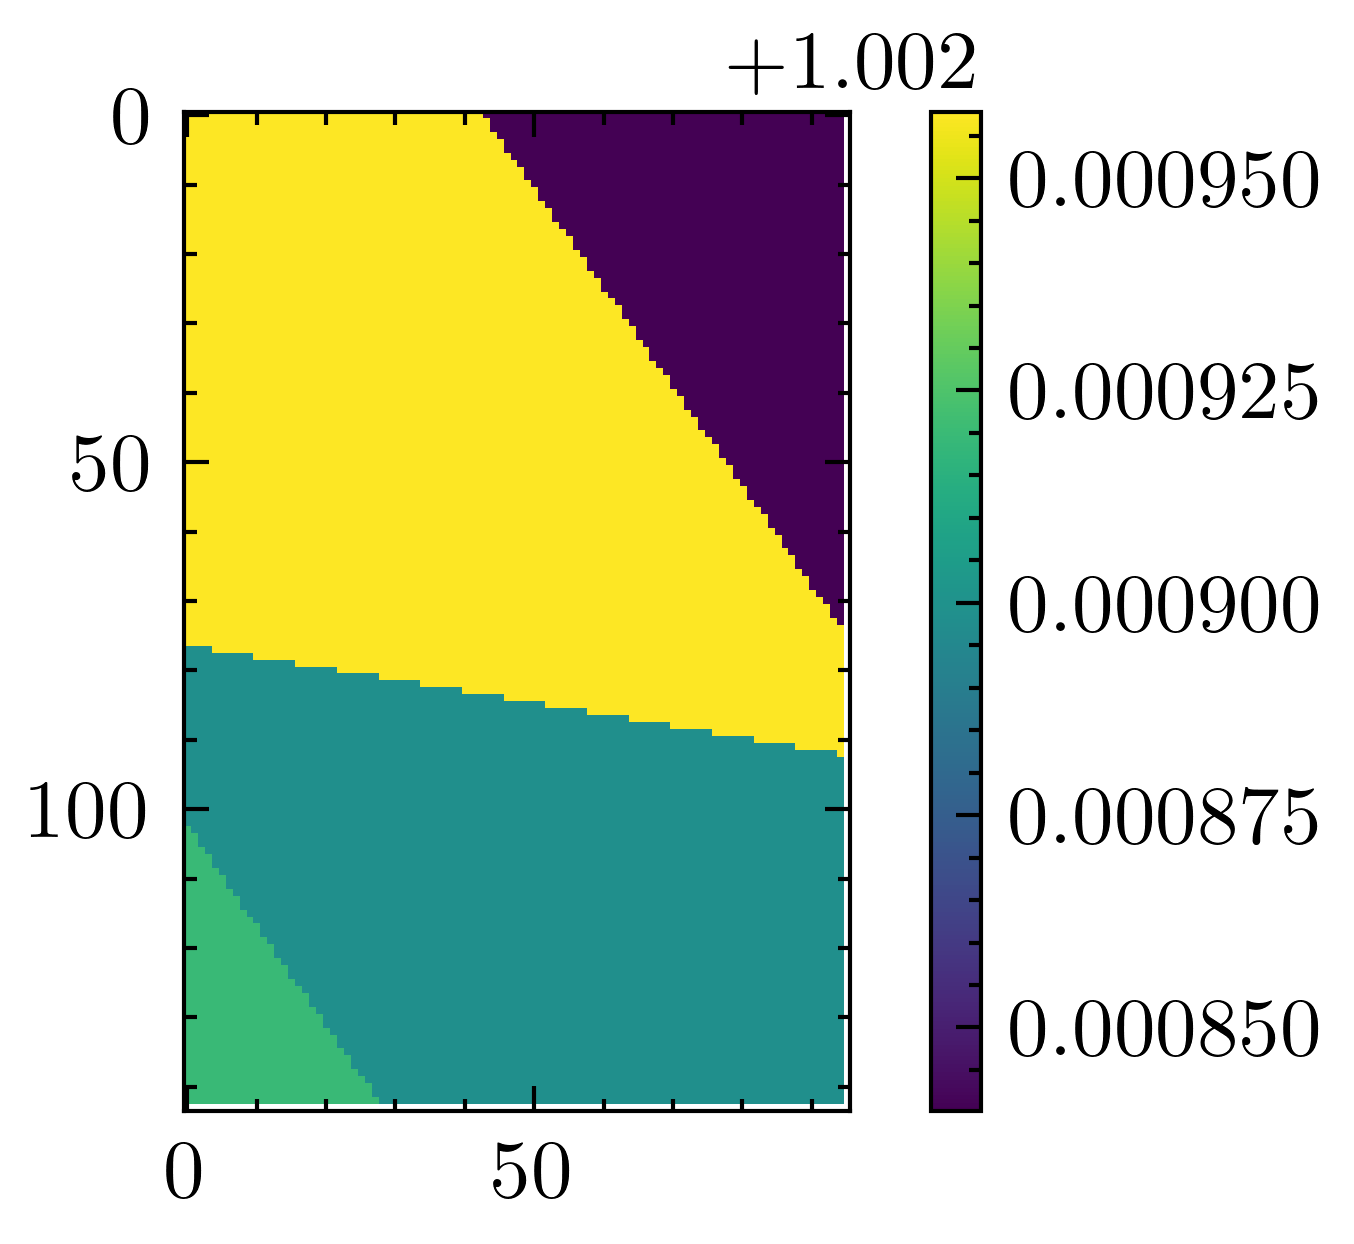

In [7]:
boulder_df = pl.scan_parquet(export_folder).filter(pl.col("boulder_id") == 40).collect()
i = boulder_df["i"].to_numpy()
j = boulder_df["j"].to_numpy()
i_min, i_max, j_min, j_max = i.min(), i.max(), j.min(), j.max()

boulder_area_df = pl.scan_parquet(export_folder).filter(
    pl.col("i") >= i_min, pl.col("i") < i_max,
    pl.col("j") >= j_min, pl.col("j") < j_max,
    pl.col("face") == boulder_df["face"].first()
).collect()

arr = np.full((i_max - i_min + 1, j_max - j_min + 1), np.nan, dtype=np.float32)
arr[boulder_area_df["i"].to_numpy() - i_min, boulder_area_df["j"].to_numpy() - j_min] = \
    boulder_area_df["detailed_survey band depth 350"].to_numpy()

plt.imshow(arr)
plt.colorbar()